<a href="https://colab.research.google.com/github/Isabela-Tellez/BootcampIA/blob/main/BootcampIA/04.%20Abril-28/Intro_SQL_Queries.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🗄️ Introducción a Bases de Datos y Queries con SQL
#### Módulo I:

---

**¿Qué vamos a aprender hoy?**

| Bloque | Contenido |
|--------|-----------|
| 🧠 Contexto | ¿Qué es una BD y por qué existe? |
| 🎬 Demo | SQL básico en vivo sobre datos reales |
| 🎯 Reto | Exploración con agregaciones |
| 🗺️ Cierre | Introducción al diseño de modelos |

**Dataset:** los mismos salarios tech con los que trabajamos en el ETL. Mismos datos, nueva herramienta.

---
# 🧠 Bloque 1 — Contexto: ¿Qué es una base de datos?

## La analogía del archivo

Imagina que trabajas en RRHH de una empresa tech con 500 empleados:

```
❌ Sin base de datos:
   Ana tiene salarios_2024_v3_FINAL.xlsx
   Bruno tiene salarios_2024_v3_FINAL_revisado.xlsx  
   Carla tiene salarios_2024_DEFINITIVO.xlsx
   → ¿Cuál es la verdad? Nadie lo sabe.

✅ Con base de datos:
   Una sola fuente de verdad.
   Todos leen y escriben en el mismo lugar.
   Los cambios quedan registrados.
```

## ¿En qué se diferencia un CSV de una base de datos?

| Característica | CSV / Excel | Base de datos relacional |
|----------------|-------------|-------------------------|
| Acceso simultáneo | ❌ Un usuario a la vez | ✅ Muchos usuarios a la vez |
| Integridad de datos | ❌ Cualquiera puede borrar lo que quiera | ✅ Reglas que protegen los datos |
| Volumen | ❌ Se rompe con millones de filas | ✅ Diseñado para escalar |
| Relaciones entre tablas | ❌ Manual (VLOOKUPs eternos) | ✅ JOINs nativos |
| Consultas complejas | ❌ Fórmulas complicadas | ✅ SQL — un lenguaje diseñado para eso |

## ¿Qué es SQL?

**SQL** (Structured Query Language) es el lenguaje con el que le hablas a una base de datos.  
No es un lenguaje de programación completo — es un lenguaje de **consultas y manipulación de datos**.

```sql
-- Así se ve una consulta SQL
-- En español: "dame el nombre y el salario de todos los seniors de España"
SELECT nombre_rol, salario_anual_eur
FROM salarios
WHERE nivel = 'Senior'
  AND pais = 'ES';
```

Si eso te resulta legible, es porque SQL está diseñado para parecerse al inglés natural.  
Es el lenguaje más usado en el mundo del dato — más que Python, más que R.

---
# ⚙️ Setup — SQLite en Colab

Vamos a usar **SQLite**: una base de datos que vive en un solo archivo (o en memoria).  
No necesita servidor, no necesita instalación — funciona directamente en Python.

En producción usaríais PostgreSQL o MySQL. SQLite es perfecta para aprender porque el SQL es exactamente el mismo.

In [ ]:
import sqlite3
import pandas as pd

# Crear una base de datos en memoria (desaparece al cerrar el notebook)
# Para que persista: sqlite3.connect('salarios.db')
conn = sqlite3.connect(':memory:')

print('✅ Conexión a SQLite lista')

✅ Conexión a SQLite lista


In [ ]:
# Cargar el CSV que ya conocemos y meterlo en la base de datos
# pd.to_sql() crea la tabla automáticamente — puente directo Pandas ↔ SQL
df = pd.read_csv('salarios_tech_limpio.csv')
df.to_sql('salarios', conn, if_exists='replace', index=False)  #El df se convierte a una tabla sql
print(f'✅ Tabla "salarios" creada con {len(df)} filas')
print(f'   Columnas: {df.columns.tolist()}')

✅ Tabla "salarios" creada con 80 filas
   Columnas: ['id', 'nombre_rol', 'departamento', 'salario_anual_eur', 'anios_experiencia', 'pais', 'empresa_tipo', 'nivel', 'modalidad_trabajo', 'anio_registro']


In [ ]:
# Función auxiliar para ejecutar SQL y ver el resultado como tabla
# La usaremos en todo el notebook
def sql(query):
    return pd.read_sql_query(query, conn).style.hide(axis='index')
print('✅ Función sql() lista — úsala así: sql("SELECT * FROM salarios")')

✅ Función sql() lista — úsala así: sql("SELECT * FROM salarios")


---
# 🎬 Bloque 2 — Demo: SQL básico

## La estructura de toda consulta SQL

```sql
SELECT  columnas_que_quiero     -- ¿Qué quiero ver?
FROM    nombre_de_la_tabla      -- ¿De dónde?
WHERE   condición               -- ¿Con qué filtro? (opcional)
ORDER BY columna ASC/DESC       -- ¿En qué orden? (opcional)
LIMIT   número                  -- ¿Cuántas filas? (opcional)
```

El orden importa: siempre en este orden, siempre.

In [ ]:
# El SELECT más básico: dame todo
# * significa "todas las columnas"
sql ("SELECT * FROM salarios")

id,nombre_rol,departamento,salario_anual_eur,anios_experiencia,pais,empresa_tipo,nivel,modalidad_trabajo,anio_registro
1,Data Analyst,Engineering,58000,11,NL,Enterprise,Mid,Presencial,2022
2,BI Developer,Product,94000,12,NL,Enterprise,Lead,Remoto,2023
3,ML Engineer,Product,46000,9,GB,Enterprise,Junior,Remoto,2024
4,BI Developer,Data,28000,9,FR,Consultora,Lead,Remoto,2021
5,BI Developer,Research,28000,2,NL,PYME,Junior,Presencial,2021
6,Data Engineer,Research,85000,7,FR,PYME,Junior,Presencial,2023
7,ML Engineer,Engineering,64000,15,FR,Consultora,Junior,Remoto,2024
8,ML Engineer,Research,52000,14,DE,Enterprise,Lead,Presencial,2021
9,ML Engineer,Engineering,34000,10,GB,Enterprise,Junior,Remoto,2024
10,BI Developer,Data,46000,3,NL,PYME,Senior,Remoto,2023


In [ ]:
# El SELECT más básico: dame todo
# * significa "todas las columnas"
sql ("""SELECT *
    FROM salarios
    LIMIT 5""")

id,nombre_rol,departamento,salario_anual_eur,anios_experiencia,pais,empresa_tipo,nivel,modalidad_trabajo,anio_registro
1,Data Analyst,Engineering,58000,11,NL,Enterprise,Mid,Presencial,2022
2,BI Developer,Product,94000,12,NL,Enterprise,Lead,Remoto,2023
3,ML Engineer,Product,46000,9,GB,Enterprise,Junior,Remoto,2024
4,BI Developer,Data,28000,9,FR,Consultora,Lead,Remoto,2021
5,BI Developer,Research,28000,2,NL,PYME,Junior,Presencial,2021


In [ ]:
# Seleccionar columnas específicas
# Equivalente en Pandas: df[['nombre_rol', 'salario_anual_eur', 'nivel']]
sql("""
SELECT nombre_rol, salario_anual_eur, nivel
FROM salarios
""")

nombre_rol,salario_anual_eur,nivel
Data Analyst,58000,Mid
BI Developer,94000,Lead
ML Engineer,46000,Junior
BI Developer,28000,Lead
BI Developer,28000,Junior
Data Engineer,85000,Junior
ML Engineer,64000,Junior
ML Engineer,52000,Lead
ML Engineer,34000,Junior
BI Developer,46000,Senior


In [ ]:
# WHERE — filtrar filas
# Equivalente en Pandas: df[df['nivel'] == 'Senior']
sql ("""
    SELECT nombre_rol, salario_Anual_eur, nivel, pais
    FROM salarios
    WHERE nivel = 'Senior'
 """)

nombre_rol,salario_anual_eur,nivel,pais
BI Developer,46000,Senior,NL
ML Engineer,49000,Senior,US
Data Analyst,82000,Senior,GB
MLOps Engineer,55000,Senior,FR
BI Developer,52000,Senior,ES
Data Scientist,34000,Senior,FR
ML Engineer,82000,Senior,GB
Data Analyst,37000,Senior,NL
BI Developer,43000,Senior,DE
Data Analyst,73000,Senior,ES


In [ ]:
# WHERE con condición numérica
sql ("""
    SELECT nombre_rol, salario_anual_eur, nivel, pais
    FROM salarios
    WHERE salario_Anual_eur  > 70000
    ORDER BY salario_Anual_eur DESC
 """)

nombre_rol,salario_anual_eur,nivel,pais
BI Developer,94000,Lead,NL
ML Engineer,94000,Mid,US
Data Engineer,94000,Junior,DE
Data Scientist,94000,Mid,DE
Data Analyst,91000,Lead,ES
MLOps Engineer,91000,Lead,FR
Data Engineer,91000,Mid,DE
ML Engineer,88000,Junior,FR
Data Engineer,85000,Junior,FR
Data Scientist,85000,Junior,US


In [ ]:
# WHERE con múltiples condiciones: AND, OR
sql("""
    SELECT nombre_rol, salario_anual_eur, nivel, pais
    FROM salarios
    WHERE nivel = 'Senior'
      AND salario_Anual_eur  > 70000
    ORDER BY salario_Anual_eur DESC
""")

nombre_rol,salario_anual_eur,nivel,pais
Data Analyst,82000,Senior,GB
ML Engineer,82000,Senior,GB
MLOps Engineer,82000,Senior,GB
Data Analyst,73000,Senior,ES


In [ ]:
# IN — equivale a varios OR seguidos
# En lugar de: WHERE pais = 'ES' OR pais = 'FR' OR pais = 'DE'
sql("""
    SELECT nombre_rol, salario_anual_eur, pais
    FROM salarios
    WHERE pais IN ('ES', 'FR', 'DE')
    ORDER BY pais, salario_anual_eur DESC
""")


nombre_rol,salario_anual_eur,pais
Data Engineer,94000,DE
Data Scientist,94000,DE
Data Engineer,91000,DE
Data Scientist,85000,DE
Data Analyst,85000,DE
Data Analyst,82000,DE
BI Developer,61000,DE
Data Analyst,58000,DE
ML Engineer,52000,DE
MLOps Engineer,46000,DE


In [ ]:
# La segunda consulta SQL
sql("""
-- Creamos una tabla temporal llamada ranking
-- para calcular una posición dentro de cada país
WITH ranking AS (
    SELECT
        nombre_rol,
        salario_anual_eur,
        nivel,
        pais,
        -- ROW_NUMBER() asigna un número a cada fila
        -- PARTITION BY pais reinicia el conteo para cada país
        -- ORDER BY salario_anual_eur DESC ordena de mayor a menor salario
        ROW_NUMBER() OVER (
            PARTITION BY pais
            ORDER BY salario_anual_eur DESC
        ) AS ranking_pais
    FROM salarios
    -- Filtramos solo los países que queremos analizar
    -- IN equivale a: pais = 'ES' OR pais = 'FR' OR pais = 'DE'
    WHERE pais IN ('ES', 'FR', 'DE')
)
-- Seleccionamos las columnas finales que queremos mostrar
SELECT
    nombre_rol,
    salario_anual_eur,
    nivel,
    pais
FROM ranking
-- Nos quedamos solo con las 5 primeras filas de cada país
WHERE ranking_pais <= 5
-- Ordenamos el resultado por país y, dentro de cada país,
-- por salario anual de mayor a menor
ORDER BY pais, salario_anual_eur DESC
""")

nombre_rol,salario_anual_eur,nivel,pais
Data Engineer,94000,Junior,DE
Data Scientist,94000,Mid,DE
Data Engineer,91000,Mid,DE
Data Scientist,85000,Mid,DE
Data Analyst,85000,Lead,DE
Data Analyst,91000,Lead,ES
Data Engineer,85000,Lead,ES
Data Analyst,76000,Lead,ES
Data Analyst,73000,Senior,ES
Data Analyst,73000,Mid,ES


In [ ]:
# LIKE — buscar texto parcial
# % es el comodín: 'Data%' = cualquier cosa que empiece por 'Data'
sql("""
    SELECT nombre_rol, salario_anual_eur, pais
    FROM salarios
    WHERE nombre_rol like 'DATA%'
    ORDER BY salario_anual_eur DESC
""")

nombre_rol,salario_anual_eur,pais
Data Engineer,94000,DE
Data Scientist,94000,DE
Data Analyst,91000,ES
Data Engineer,91000,DE
Data Engineer,85000,FR
Data Scientist,85000,US
Data Scientist,85000,DE
Data Analyst,85000,DE
Data Engineer,85000,ES
Data Analyst,82000,GB


---
## Agregaciones — aquí empieza el análisis real

Las funciones de agregación **resumen muchas filas en un solo número**.

| Función SQL | Equivalente Pandas | Qué hace |
|-------------|-------------------|----------|
| `COUNT(*)` | `len(df)` | Cuenta filas |
| `SUM(col)` | `df['col'].sum()` | Suma valores |
| `AVG(col)` | `df['col'].mean()` | Promedio |
| `MAX(col)` | `df['col'].max()` | Valor máximo |
| `MIN(col)` | `df['col'].min()` | Valor mínimo |

In [ ]:
# COUNT — cuántos registros hay
sql("""
    SELECT COUNT (*) AS total_profesionales FROM salarios
""")

total_profesionales
80


In [ ]:
# AVG, MAX, MIN sobre salarios
sql("""
SELECT
    CAST (ROUND(AVG(salario_anual_eur), 0) AS INTEGER)    AS salario_medio,
    MAX(salario_anual_eur)                                AS salario_maximo,
    MIN(salario_anual_eur)                                AS salario_minimo
FROM salarios
""")

salario_medio,salario_maximo,salario_minimo
57963,94000,28000


In [ ]:
# GROUP BY — el equivalente SQL de .groupby() en Pandas
# "Dame el salario promedio por nivel de experiencia"
sql("""
SELECT
    nivel,
    COUNT(*)                          AS total,
    ROUND(AVG(salario_anual_eur), 0)  AS salario_medio
FROM salarios
GROUP BY nivel
ORDER BY salario_medio DESC
""")

nivel,total,salario_medio
Mid,21,65857.000000
Senior,12,57000.000000
Junior,21,56143.000000
Lead,26,53500.000000


In [ ]:
# HAVING — filtrar GRUPOS (no filas individuales)
# Diferencia clave:
#   WHERE filtra filas ANTES de agrupar
#   HAVING filtra grupos DESPUÉS de agrupar
#
# "Roles con más de 5 profesionales y salario medio > 60.000€"
sql("""
SELECT
    nombre_rol,
    COUNT(*)                                                AS total,
    CAST (ROUND(AVG(salario_anual_eur), 0) AS INTEGER)      AS salario_medio
FROM salarios
GROUP BY nombre_rol
HAVING total > 5
   AND salario_medio > 60000
ORDER BY salario_medio DESC
""")


nombre_rol,total,salario_medio
MLOps Engineer,13,61231
ML Engineer,11,60727
Data Analyst,20,60550


<details><summary>💡 Pista</summary>



La salida esperada:





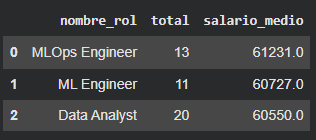


</details>

---
# 🎯 Reto de Exploración

---

### Contexto 🏢
Sois analistas de datos en una consultora de RRHH tech.  
El cliente quiere un **informe express** sobre el mercado laboral basado en vuestro dataset.

---

### 🟢 Nivel 1 — Preguntas directas (SELECT + WHERE + ORDER BY)

In [ ]:
# 1A — ¿Cuántos profesionales hay en el dataset en total?
# Tu consulta aquí ↓
sql ("""
    SELECT COUNT(*) AS total_profesionales
    FROM salarios;
 """)

total_profesionales
80


In [ ]:
# 1B — Lista todos los Data Scientists ordenados por salario de mayor a menor
# Muestra solo: nombre_rol, salario_anual_eur, pais, nivel
# Tu consulta aquí ↓
sql ("""
    SELECT nombre_rol, salario_anual_eur, pais, nivel
    FROM salarios
    WHERE nombre_rol = 'Data Scientist'
    ORDER BY salario_anual_eur DESC;
 """)

nombre_rol,salario_anual_eur,pais,nivel
Data Scientist,94000,DE,Mid
Data Scientist,85000,US,Junior
Data Scientist,85000,DE,Mid
Data Scientist,43000,ES,Mid
Data Scientist,34000,FR,Senior
Data Scientist,34000,DE,Junior
Data Scientist,31000,NL,Junior
Data Scientist,28000,GB,Junior


In [ ]:
# 1C — ¿Qué profesionales trabajan en remoto Y cobran más de 70.000€?
# Tu consulta aquí ↓
sql ("""
    SELECT * FROM salarios
    WHERE modalidad_trabajo = 'Remoto'
      AND salario_anual_eur > 70000
    ORDER BY salario_anual_eur DESC
 """)

id,nombre_rol,departamento,salario_anual_eur,anios_experiencia,pais,empresa_tipo,nivel,modalidad_trabajo,anio_registro
2,BI Developer,Product,94000,12,NL,Enterprise,Lead,Remoto,2023
37,MLOps Engineer,Engineering,91000,4,FR,Enterprise,Lead,Remoto,2022
25,MLOps Engineer,Data,85000,7,GB,Enterprise,Junior,Remoto,2022
73,Data Engineer,Research,85000,12,ES,Startup,Lead,Remoto,2023
42,ML Engineer,Analytics,82000,6,GB,Consultora,Senior,Remoto,2023
23,Data Analyst,Analytics,76000,5,US,PYME,Mid,Remoto,2022
32,Data Engineer,Engineering,76000,8,GB,Startup,Mid,Remoto,2022
51,MLOps Engineer,Analytics,76000,13,NL,PYME,Mid,Remoto,2022
60,Data Analyst,Research,73000,4,ES,Consultora,Mid,Remoto,2021
64,MLOps Engineer,Analytics,73000,14,GB,Startup,Junior,Remoto,2023


### 🟡 Nivel 2 — Análisis por grupos (GROUP BY + HAVING)

In [ ]:
# 2A — ¿Cuál es el salario medio por modalidad de trabajo (remoto, híbrido, presencial)?
# Ordena de mayor a menor salario medio
# Tu consulta aquí ↓
sql ("""
    SELECT modalidad_trabajo,
      CAST (ROUND(AVG(salario_anual_eur), 0) AS INTEGER) AS salario_medio
    FROM salarios
    GROUP BY modalidad_trabajo
    ORDER BY salario_medio DESC
""")

modalidad_trabajo,salario_medio
Híbrido,64316
Presencial,59920
Remoto,53250


In [ ]:
# 2B — ¿En qué países hay más de 10 profesionales en el dataset?
# Muestra el país y el total de profesionales
# Pista: necesitas HAVING
# Tu consulta aquí ↓ç
sql ("""
    SELECT pais,
        COUNT(*) AS total_profesionales
    FROM salarios
    GROUP BY pais
    HAVING total_profesionales > 10
    ORDER BY total_profesionales DESC
""")


pais,total_profesionales
ES,15
NL,14
GB,14
DE,13
US,12
FR,12


In [ ]:
# 2C — Para cada tipo de empresa (Startup, PYME, Enterprise, Consultora):
# muestra el total de empleados, el salario medio y el salario máximo
# Ordena por salario medio descendente
# Tu consulta aquí ↓
sql ("""
    SELECT
        empresa_tipo,
        COUNT(*)                                              AS total_empleados,
        CAST (ROUND(AVG(salario_anual_eur), 0) AS INTEGER)    AS salario_medio,
        MAX(salario_anual_eur)                                AS salario_maximo
    FROM salarios
    GROUP BY empresa_tipo
    ORDER BY salario_medio DESC
""")

empresa_tipo,total_empleados,salario_medio,salario_maximo
Consultora,19,63211,94000
Startup,16,59313,85000
Enterprise,20,57850,94000
PYME,25,53200,91000


---
# 🗺️ Bloque 3 — Introducción al Diseño de Modelos

Hasta ahora hemos trabajado con **una sola tabla**. En el mundo real, los datos viven en **muchas tablas relacionadas entre sí**.

## ¿Por qué varias tablas?

Imagina que en lugar de una tabla tienes esta situación:

```
❌ Una sola tabla (problema):
┌────────────┬──────────────┬──────────────────────────────┬──────────────────────────────┐
│ empleado   │ departamento │ jefe_departamento            │ email_jefe                   │
├────────────┼──────────────┼──────────────────────────────┼──────────────────────────────┤
│ Ana        │ Data         │ Carlos García                │ carlos@empresa.com           │
│ Bruno      │ Data         │ Carlos García                │ carlos@empresa.com           │
│ Carla      │ Data         │ Carlos García                │ carlos@empresa.com           │
│ David      │ Engineering  │ Laura Martínez               │ laura@empresa.com            │
└────────────┴──────────────┴──────────────────────────────┴──────────────────────────────┘
El nombre y email del jefe se repite para cada empleado → duplicación, inconsistencias
```

```
✅ Dos tablas relacionadas (solución):

EMPLEADOS                          DEPARTAMENTOS
┌────┬───────┬──────────────┐      ┌────┬──────────────┬────────────────┐
│ id │nombre │ depto_id  FK─┼──────┼▶ id│ nombre       │ jefe           │
├────┼───────┼──────────────┤      ├────┼──────────────┼────────────────┤
│  1 │ Ana   │     1        │      │  1 │ Data         │ Carlos García  │
│  2 │ Bruno │     1        │      │  2 │ Engineering  │ Laura Martínez │
│  3 │ Carla │     1        │      └────┴──────────────┴────────────────┘
│  4 │ David │     2        │
└────┴───────┴──────────────┘
depto_id (FK) = Foreign Key (clave foránea) — el enlace entre tablas

```

## Conceptos clave

| Concepto | Qué es |
|----------|--------|
| **Clave primaria** (PK) | Identificador único de cada fila. Nunca se repite. |
| **Clave foránea** (FK) | Columna que referencia la PK de otra tabla. El enlace. |
| **Relación 1:N** | Un departamento tiene muchos empleados. |
| **Relación N:M** | Un empleado puede tener muchos proyectos y un proyecto muchos empleados. |


---
## 👀 Preview — ¿Cómo se unen dos tablas en SQL?

Con un `JOIN`. Vamos a verlo con un ejemplo rápido antes de terminar.

In [ ]:
# Crear dos tablas relacionadas para el preview
empleados_df = pd.DataFrame({
    'id':       [1, 2, 3, 4, 5],
    'nombre':   ['Ana', 'Bruno', 'Carla', 'David', 'Elena'],
    'depto_id': [1, 1, 2, 2, 3],
    'salario':  [45000, 62000, 78000, 55000, 91000]
})

departamentos_df = pd.DataFrame({
    'id':     [1, 2, 3],
    'nombre': ['Data', 'Engineering', 'Research'],
    'ciudad': ['Madrid', 'Barcelona', 'Berlín']
})

empleados_df.to_sql('empleados',     conn, if_exists='replace', index=False)
departamentos_df.to_sql('departamentos', conn, if_exists='replace', index=False)

print('Tabla empleados:')
display(empleados_df)
print('Tabla departamentos:')
display(departamentos_df)

Tabla empleados:


,id,nombre,depto_id,salario
0,1,Ana,1,45000
1,2,Bruno,1,62000
2,3,Carla,2,78000
3,4,David,2,55000
4,5,Elena,3,91000


Tabla departamentos:


,id,nombre,ciudad
0,1,Data,Madrid
1,2,Engineering,Barcelona
2,3,Research,Berlín


In [ ]:
# JOIN — cruzar las dos tablas por la clave foránea
# "Dame nombre del empleado, su salario y el nombre de su departamento"
sql("""
SELECT
    e.nombre     AS empleado,
    e.salario,
    d.nombre     AS departamento,
    d.ciudad
FROM empleados e
JOIN departamentos d ON e.depto_id = d.id
ORDER BY e.salario DESC
""")

empleado,salario,departamento,ciudad
Elena,91000,Research,Berlín
Carla,78000,Engineering,Barcelona
Bruno,62000,Data,Madrid
David,55000,Engineering,Barcelona
Ana,45000,Data,Madrid


---
## 📚 Resumen de la sesión — SQL en una página

```sql
-- ESTRUCTURA COMPLETA DE UNA CONSULTA
SELECT  columnas, ROUND(AVG(col), 0) AS alias   -- qué quiero ver
FROM    tabla                                     -- de dónde
WHERE   condicion = 'valor'                       -- filtro de filas (antes de agrupar)
GROUP BY columna_categorica                       -- agrupar
HAVING  COUNT(*) > 5                             -- filtro de grupos (después de agrupar)
ORDER BY alias DESC                              -- ordenar
LIMIT   10;                                      -- limitar resultado
```

| Concepto | Para qué sirve |
|----------|----------------|
| `SELECT / FROM / WHERE` | La triada básica de toda consulta |
| `ORDER BY / LIMIT` | Controlar orden y cantidad de resultados |
| `IN`, `BETWEEN`, `LIKE` | Filtros avanzados en WHERE |
| `COUNT`, `AVG`, `SUM`, `MAX`, `MIN` | Resumir datos numéricos |
| `GROUP BY` | Agrupar filas para agregar |
| `HAVING` | Filtrar grupos (≠ WHERE que filtra filas) |
| `WITH ... AS` (CTE) | Organizar consultas complejas en pasos |
| `RANK() OVER (PARTITION BY ...)` | Funciones de ventana — ranking por grupo |
| `JOIN ... ON` | Cruzar datos de dos tablas |

---


# Documentación de apoyo :





1. **Documentación oficial de SQLite — Lenguaje SQL**
https://sqlite.org/lang.html SQLite
La referencia completa del SQL que entiende SQLite. Cubre toda la sintaxis de SELECT, WHERE, JOIN, GROUP BY, HAVING, subconsultas y funciones de ventana. Es la fuente de verdad — si tienes duda sobre si algo funciona en SQLite, aquí está la respuesta.

2. **sqlite3 en Python — Documentación oficial de Python**
https://docs.python.org/3/library/sqlite3.html Python documentation
La documentación oficial del módulo sqlite3 de Python — exactamente la librería que usamos en clase con conn, cursor, execute() y fetchall(). Tiene tutorial, referencia completa y guías de casos concretos.

3. **SQLite Tutorial — Referencia práctica de consultas**
https://www.sqlitetutorial.net/ SQLite Tutorial
El recurso más didáctico de los cinco. Cubre SELECT, ORDER BY, WHERE, AND/OR, LIMIT, GROUP BY, HAVING, JOIN y subconsultas — exactamente el contenido del martes — con ejemplos ejecutables para cada concepto.



4. [SQL Ejercicios](https://www.w3schools.com/sql/)